THÔNG TIN DỮ LIỆU
Số hàng (quan sát): 300
Số cột (biến):      12

Các cột trong dataset:
['time', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10', 'y']

5 dòng đầu tiên:
   time        x1        x2        x3        x4        x5        x6        x7  \
0     0 -0.001129 -0.067168  0.068116 -0.049255 -0.154987 -0.084791  0.401000   
1     1 -0.033521  0.002889 -0.355931 -0.021399 -0.325739 -0.051217  0.172194   
2     2 -0.215158  0.505988 -0.484005  0.072329 -0.259608 -0.098098  0.042182   
3     3 -0.384662  0.114156 -0.740316 -0.049414 -0.086604 -0.193263 -0.136511   
4     4 -0.901311  0.943390 -0.304578  0.488667 -0.142681 -0.061110  0.171175   

         x8        x9       x10            y  
0  0.344718 -0.073794 -0.334057  2759.531131  
1  0.207707 -0.261801  0.054236  2795.597841  
2  0.134361 -0.096544  0.023329  2827.973813  
3 -0.216451  0.266156  0.320760  2872.399288  
4  0.445352  0.546365  0.914837  2908.625975  

Kiểm tra giá trị bị thiếu (NaN):
time    0
x1   

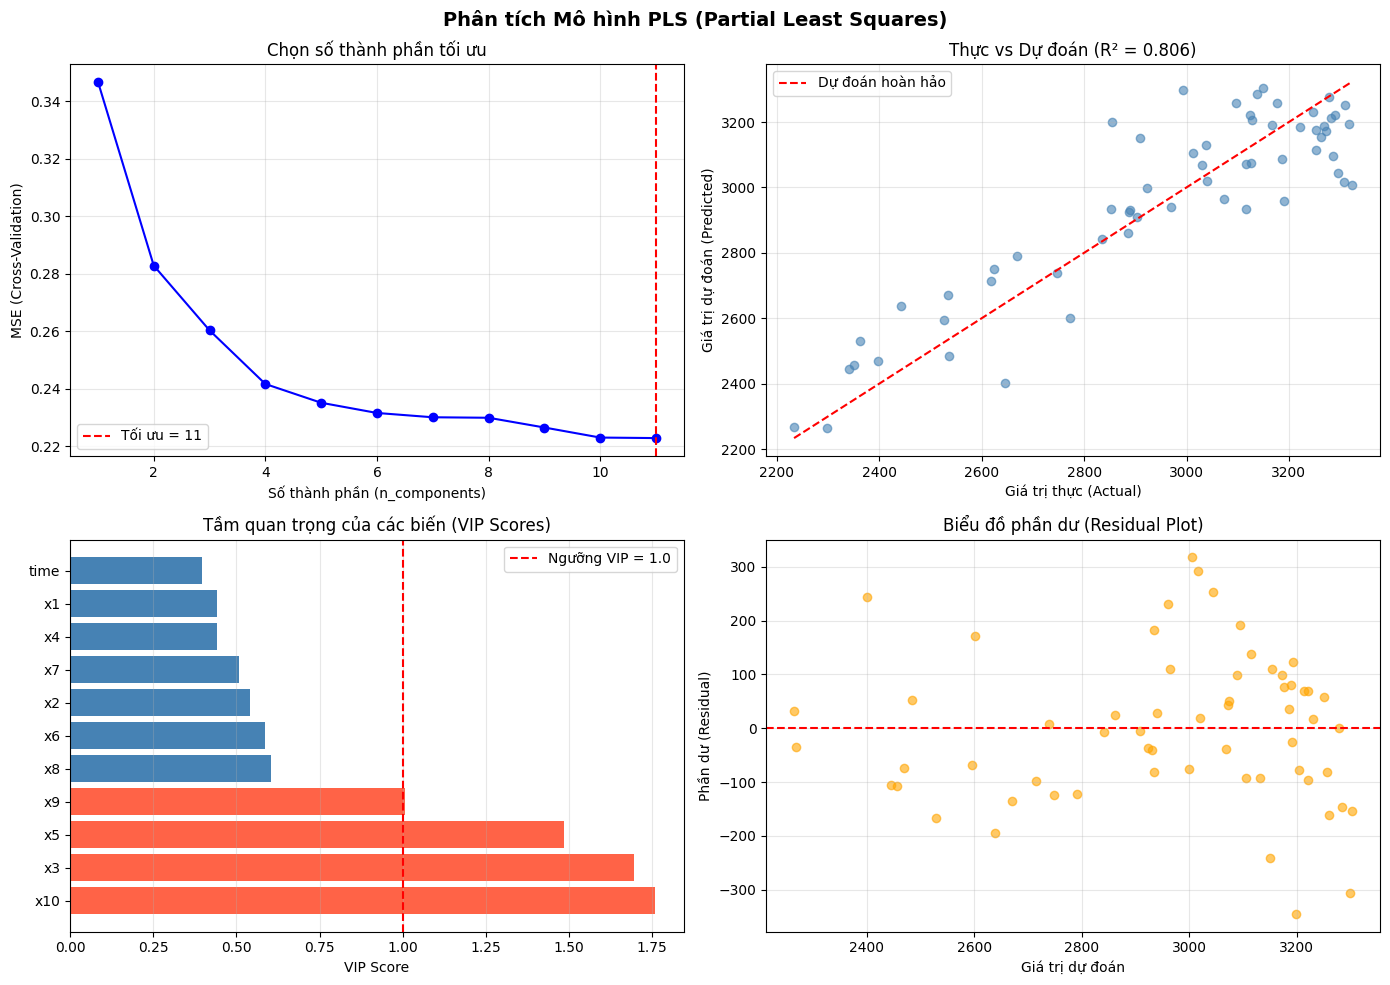


Biểu đồ đã được lưu: pls_results.png

X-LOADINGS (mỗi cột = 1 thành phần PLS)
      Thành phần 1  Thành phần 2  Thành phần 3  Thành phần 4  Thành phần 5  \
time        0.1279       -0.4410        0.2224        0.1240        0.0656   
x1         -0.1117        0.3165        0.2462        0.0417       -0.7114   
x2         -0.0060        0.4224       -0.1801        0.4375       -0.2251   
x3         -0.4829       -0.2143        0.1752       -0.0124       -0.6175   
x4         -0.0619        0.4141       -0.2836       -0.3595       -0.1464   
x5          0.5608       -0.2247        0.1346       -0.2181       -0.6868   
x6         -0.2682        0.3879       -0.3127        0.1571        0.1417   
x7         -0.1700        0.4218       -0.0523       -0.6588       -0.1366   
x8          0.2131       -0.3253        0.4545       -0.2783       -0.1835   
x9          0.1368        0.0977        0.6316        0.7616        0.5958   
x10         0.6907       -0.1412       -0.4147       -0.0423   

In [2]:
# =============================================================================
# MÔ HÌNH PLS (Partial Least Squares Regression)
# =============================================================================
# PLS là phương pháp hồi quy kết hợp giữa PCA và hồi quy tuyến tính.
# Nó tìm các "thành phần ẩn" (latent components) từ X sao cho:
#   - Giải thích được nhiều phương sai trong X (như PCA)
#   - Đồng thời tương quan cao nhất có thể với Y
#
# Khi nào dùng PLS?
#   - Khi số biến X (features) nhiều hơn số quan sát (n < p)
#   - Khi các biến X có tương quan cao với nhau (multicollinearity)
#   - Khi bạn muốn dự đoán Y từ nhiều biến X cùng lúc
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# =============================================================================
# BƯỚC 1: IMPORT DỮ LIỆU TỪ FILE CSV
# =============================================================================

# Đọc file CSV vào DataFrame
# Thay 'your_data.csv' bằng đường dẫn thực tế đến file của bạn
df = pd.read_csv('synthetic_data.csv')

print("=" * 60)
print("THÔNG TIN DỮ LIỆU")
print("=" * 60)
print(f"Số hàng (quan sát): {df.shape[0]}")
print(f"Số cột (biến):      {df.shape[1]}")
print("\nCác cột trong dataset:")
print(df.columns.tolist())
print("\n5 dòng đầu tiên:")
print(df.head())
print("\nKiểm tra giá trị bị thiếu (NaN):")
print(df.isnull().sum())

# =============================================================================
# BƯỚC 2: CHUẨN BỊ DỮ LIỆU
# =============================================================================
# !! CHỈNH SỬA PHẦN NÀY theo dataset của bạn !!
# Giả sử cột cuối cùng là biến mục tiêu Y, các cột còn lại là X

# Tách X (biến đầu vào) và Y (biến mục tiêu)
# Ví dụ: target_column = 'ten_cot_Y'  <- thay bằng tên cột thực tế
target_column = df.columns[-1]   # Lấy cột cuối làm Y (có thể đổi lại)
feature_columns = [col for col in df.columns if col != target_column]

X = df[feature_columns].values   # Ma trận đặc trưng (n x p)
y = df[target_column].values     # Véc-tơ mục tiêu (n,)

print(f"\nBiến mục tiêu (Y): {target_column}")
print(f"Biến đầu vào (X): {feature_columns}")
print(f"Shape của X: {X.shape}")
print(f"Shape của y: {y.shape}")

# =============================================================================
# BƯỚC 3: CHUẨN HÓA DỮ LIỆU (Standardization)
# =============================================================================
# PLS rất nhạy cảm với đơn vị đo lường.
# StandardScaler chuyển mỗi biến về: mean=0, std=1
# Công thức: X_scaled = (X - mean) / std

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)          # Chuẩn hóa X
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()  # Chuẩn hóa Y

# =============================================================================
# BƯỚC 4: CHIA DỮ LIỆU TRAIN/TEST
# =============================================================================
# 80% train, 20% test — random_state đảm bảo kết quả tái lập được

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)

print(f"\nTrain set: {X_train.shape[0]} mẫu")
print(f"Test set:  {X_test.shape[0]} mẫu")

# =============================================================================
# BƯỚC 5: CHỌN SỐ THÀNH PHẦN TỐI ƯU (n_components)
# =============================================================================
# "n_components" là số chiều ẩn (latent variables) mà PLS sẽ trích xuất.
# - Quá ít: mô hình không học đủ (underfitting)
# - Quá nhiều: mô hình học thuộc dữ liệu train (overfitting)
#
# Dùng Cross-Validation (CV) để tìm số thành phần tốt nhất:
# CV chia train set thành k fold, train k lần, mỗi lần test 1 fold.

max_components = min(X_train.shape[0], X_train.shape[1], 20)  # giới hạn an toàn
mse_cv = []  # lưu MSE trung bình cho từng n_components

print("\nTìm số thành phần tối ưu bằng 10-Fold Cross-Validation...")

for n in range(1, max_components + 1):
    pls_temp = PLSRegression(n_components=n)
    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    
    # cross_val_score trả về mảng score (negative MSE) cho mỗi fold
    scores = cross_val_score(pls_temp, X_train, y_train,
                             cv=kf, scoring='neg_mean_squared_error')
    mse_cv.append(-scores.mean())  # chuyển về MSE dương

optimal_n = np.argmin(mse_cv) + 1  # +1 vì index bắt đầu từ 0
print(f"Số thành phần tối ưu: {optimal_n} (MSE_CV = {mse_cv[optimal_n-1]:.4f})")

# =============================================================================
# BƯỚC 6: XÂY DỰNG MÔ HÌNH PLS CUỐI CÙNG
# =============================================================================
# PLSRegression từ scikit-learn sử dụng thuật toán NIPALS (Nonlinear Iterative
# Partial Least Squares) để tìm các loading vectors W, P, Q và scores T, U.
#
# Công thức cốt lõi:
#   X = T * P^T + E_x   (T: X-scores, P: X-loadings, E_x: residuals X)
#   Y = U * Q^T + E_y   (U: Y-scores, Q: Y-loadings, E_y: residuals Y)
#   T và U được tìm sao cho cov(T, U) là lớn nhất.

pls_model = PLSRegression(n_components=optimal_n)
pls_model.fit(X_train, y_train)

print(f"\nMô hình PLS đã được huấn luyện với {optimal_n} thành phần.")

# =============================================================================
# BƯỚC 7: ĐÁNH GIÁ MÔ HÌNH
# =============================================================================

# Dự đoán trên tập test
y_pred_scaled = pls_model.predict(X_test).ravel()

# Chuyển lại đơn vị gốc (inverse transform)
y_pred_original = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
y_test_original = scaler_y.inverse_transform(y_test.reshape(-1, 1)).ravel()

# Tính các chỉ số đánh giá
mse_test  = mean_squared_error(y_test_original, y_pred_original)
rmse_test = np.sqrt(mse_test)
r2_test   = r2_score(y_test_original, y_pred_original)

print("\n" + "=" * 60)
print("KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST")
print("=" * 60)
print(f"MSE  (Mean Squared Error):       {mse_test:.4f}")
print(f"RMSE (Root MSE):                 {rmse_test:.4f}")
print(f"R²   (Hệ số xác định):           {r2_test:.4f}")
print("→ R² càng gần 1 thì mô hình càng tốt")

# =============================================================================
# BƯỚC 8: TRÍCH XUẤT THÔNG TIN BÊN TRONG MÔ HÌNH
# =============================================================================
# VIP (Variable Importance in Projection) đo lường mức độ đóng góp
# của từng biến X vào khả năng giải thích Y.
# VIP > 1.0 → biến đó quan trọng

def calculate_vip(pls_model, X):
    """Tính VIP scores cho từng biến đầu vào."""
    T = pls_model.x_scores_          # Ma trận X-scores (n x n_components)
    W = pls_model.x_weights_          # Ma trận X-weights (p x n_components)
    Q = pls_model.y_loadings_         # Ma trận Y-loadings (1 x n_components)
    
    p = W.shape[0]                    # Số biến X
    n_comp = T.shape[1]               # Số thành phần
    
    # SSY: tổng phương sai Y được giải thích bởi mỗi thành phần
    SSY = np.sum(T**2, axis=0) * np.sum(Q**2, axis=0)
    SSY_total = np.sum(SSY)
    
    # Tính VIP cho từng biến
    vip = np.sqrt(p * np.sum(SSY * (W**2), axis=1) / SSY_total)
    return vip

vip_scores = calculate_vip(pls_model, X_train)

# In VIP scores
print("\n" + "=" * 60)
print("VIP SCORES (Variable Importance in Projection)")
print("=" * 60)
vip_df = pd.DataFrame({
    'Biến': feature_columns,
    'VIP Score': vip_scores
}).sort_values('VIP Score', ascending=False)
print(vip_df.to_string(index=False))
print("\n→ Biến có VIP > 1.0 được xem là quan trọng cho mô hình")

# =============================================================================
# BƯỚC 9: TRỰC QUAN HÓA KẾT QUẢ
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Phân tích Mô hình PLS (Partial Least Squares)', fontsize=14, fontweight='bold')

# --- Biểu đồ 1: MSE Cross-Validation theo số thành phần ---
ax1 = axes[0, 0]
ax1.plot(range(1, max_components + 1), mse_cv, 'bo-', markersize=6)
ax1.axvline(x=optimal_n, color='red', linestyle='--', label=f'Tối ưu = {optimal_n}')
ax1.set_xlabel('Số thành phần (n_components)')
ax1.set_ylabel('MSE (Cross-Validation)')
ax1.set_title('Chọn số thành phần tối ưu')
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Biểu đồ 2: Giá trị thực vs Giá trị dự đoán ---
ax2 = axes[0, 1]
ax2.scatter(y_test_original, y_pred_original, alpha=0.6, color='steelblue')
# Đường 45° = dự đoán hoàn hảo
min_val = min(y_test_original.min(), y_pred_original.min())
max_val = max(y_test_original.max(), y_pred_original.max())
ax2.plot([min_val, max_val], [min_val, max_val], 'r--', label='Dự đoán hoàn hảo')
ax2.set_xlabel('Giá trị thực (Actual)')
ax2.set_ylabel('Giá trị dự đoán (Predicted)')
ax2.set_title(f'Thực vs Dự đoán (R² = {r2_test:.3f})')
ax2.legend()
ax2.grid(True, alpha=0.3)

# --- Biểu đồ 3: VIP Scores ---
ax3 = axes[1, 0]
colors = ['tomato' if v > 1.0 else 'steelblue' for v in vip_df['VIP Score']]
ax3.barh(vip_df['Biến'], vip_df['VIP Score'], color=colors)
ax3.axvline(x=1.0, color='red', linestyle='--', label='Ngưỡng VIP = 1.0')
ax3.set_xlabel('VIP Score')
ax3.set_title('Tầm quan trọng của các biến (VIP Scores)')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='x')

# --- Biểu đồ 4: Residuals (Phần dư) ---
ax4 = axes[1, 1]
residuals = y_test_original - y_pred_original
ax4.scatter(y_pred_original, residuals, alpha=0.6, color='orange')
ax4.axhline(y=0, color='red', linestyle='--')
ax4.set_xlabel('Giá trị dự đoán')
ax4.set_ylabel('Phần dư (Residual)')
ax4.set_title('Biểu đồ phần dư (Residual Plot)')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pls_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nBiểu đồ đã được lưu: pls_results.png")

# =============================================================================
# BƯỚC 10: LOADINGS - Hiểu mối quan hệ giữa biến và thành phần
# =============================================================================
# X-loadings: mỗi thành phần là tổ hợp tuyến tính nào của các biến X?
print("\n" + "=" * 60)
print("X-LOADINGS (mỗi cột = 1 thành phần PLS)")
print("=" * 60)
loadings_df = pd.DataFrame(
    pls_model.x_loadings_,
    index=feature_columns,
    columns=[f'Thành phần {i+1}' for i in range(optimal_n)]
)
print(loadings_df.round(4))

# =============================================================================
# TÓM TẮT CÁCH PLS HOẠT ĐỘNG
# =============================================================================
print("\n" + "=" * 60)
print("TÓM TẮT: PLS HOẠT ĐỘNG NHƯ THẾ NÀO?")
print("=" * 60)
print("""
1. NIPALS Algorithm: PLS lặp đi lặp lại để tìm cặp vectors (w, q) sao cho
   cov(Xw, Yq) là lớn nhất. Đây là bước 'partial least squares'.

2. Deflation: Sau mỗi thành phần, PLS trừ đi phần mà thành phần đó giải thích
   khỏi X và Y, rồi tiếp tục tìm thành phần tiếp theo trên phần dư.

3. Kết quả: n_components vectors trực giao, mỗi cái capture nhiều covariance
   nhất có thể giữa X và Y.

4. Prediction: Y_pred = T * B_pls, trong đó T là X-scores và B_pls
   là ma trận hệ số hồi quy trong không gian latent.
""")

print("Script hoàn tất! Hãy thay 'your_data.csv' và 'target_column' cho phù hợp.")

X shape: (300, 10)
y — min: 2207.57, max: 3398.28, mean: 2916.33

Tìm n_components tối ưu (10-Fold CV)...
→ n_components tối ưu: 7

KẾT QUẢ SO SÁNH
                             MyPLS       Sklearn
R²                        0.799042      0.799042
RMSE                      140.0752      140.0752
Sai lệch R²               0.00e+00
→ Kết quả khớp hoàn toàn ✓

Max diff giữa beta (MyPLS vs Sklearn): 5.55e-16

VIP Scores (biến nào quan trọng?):
  x10  : 1.4026  ████████████████ ← QUAN TRỌNG
  x3   : 1.3006  ███████████████ ← QUAN TRỌNG
  x5   : 1.1680  ██████████████ ← QUAN TRỌNG
  x7   : 1.1222  █████████████ ← QUAN TRỌNG
  x9   : 0.9567  ███████████
  x4   : 0.8622  ██████████
  x1   : 0.8563  ██████████
  x2   : 0.7169  ████████
  x6   : 0.7092  ████████
  x8   : 0.5556  ██████


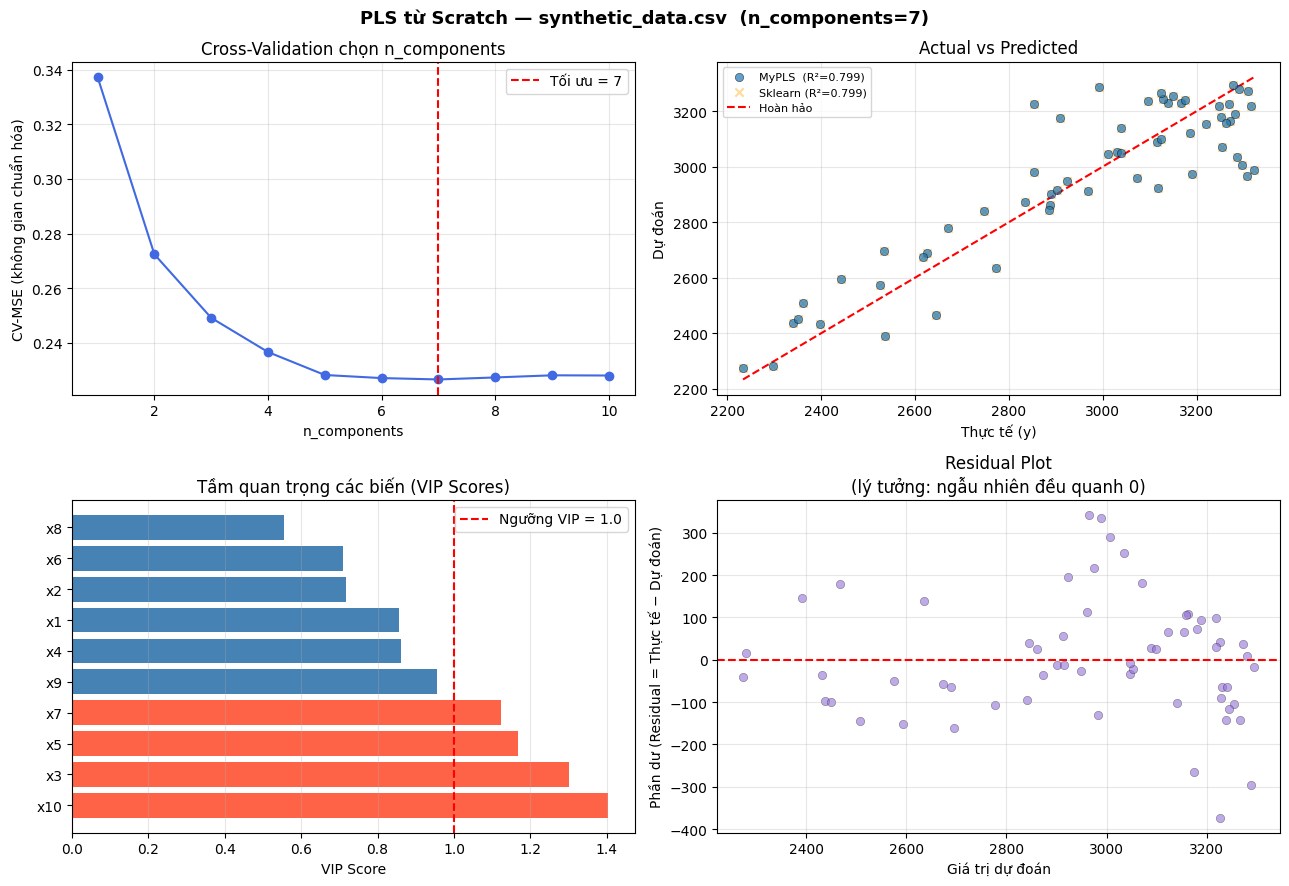


Biểu đồ đã lưu: pls_v3_results.png


In [ ]:
# =============================================================================
# PLS TỰ VIẾT (NIPALS) — khớp hoàn toàn với scikit-learn PLSRegression
# Dataset: synthetic_data.csv  |  Features: x1-x10  |  Target: y
# =============================================================================
# LỖI ĐÃ TÌM RA VÀ SỬA:
#   Code cũ normalize q (chia ||q||) rồi deflate Y bằng: Y -= outer(t, q)
#   Sklearn KHÔNG normalize q, và deflate Y bằng: Y -= b * outer(t, q)
#   trong đó b = (u^T t) / (t^T t)  là "inner relation coefficient"
#   → Sai deflation làm tích lũy sai số từ component 2 trở đi
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.cross_decomposition import PLSRegression as SklearnPLS


# =============================================================================
# BƯỚC 1: ĐỌC DỮ LIỆU
# =============================================================================
df = pd.read_csv('synthetic_data.csv')

feature_cols = ['x1','x2','x3','x4','x5','x6','x7','x8','x9','x10']
target_col   = 'y'

X_raw = df[feature_cols].values
y_raw = df[target_col].values

print(f"X shape: {X_raw.shape}")
print(f"y — min: {y_raw.min():.2f}, max: {y_raw.max():.2f}, mean: {y_raw.mean():.2f}")

X_tr, X_te, y_tr, y_te = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42)


# =============================================================================
# BƯỚC 2: CHUẨN HÓA (chỉ 1 lần, dùng mean/std của train)
# =============================================================================
x_mean = X_tr.mean(axis=0)
x_std  = X_tr.std(axis=0, ddof=0)   # ddof=0 khớp với sklearn
x_std[x_std == 0] = 1

y_mean = y_tr.mean()
y_std  = y_tr.std(ddof=0)

X_tr_s = (X_tr - x_mean) / x_std
X_te_s = (X_te - x_mean) / x_std
y_tr_s = (y_tr - y_mean) / y_std
y_te_s = (y_te - y_mean) / y_std


# =============================================================================
# BƯỚC 3: NIPALS — ĐÚNG THEO SKLEARN SOURCE CODE
# =============================================================================
def nipals_pls(X, Y, n_components, tol=1e-10, max_iter=1000):
    """
    NIPALS algorithm khớp hoàn toàn với sklearn PLSRegression.

    Điểm mấu chốt so với các tài liệu thông thường:

    (1) q KHÔNG được chuẩn hóa (không chia ||q||)
        → q = Y^T t   (giữ nguyên độ lớn)
        → u = Y q / (q^T q)   (bù lại để u có đúng tỉ lệ)

    (2) Deflation Y dùng "inner relation coefficient" b:
        b = (u^T t) / (t^T t)   ← hệ số hồi quy u ~ b*t
        Y_new = Y - b * t * q^T

    (3) Hệ số hồi quy cuối:
        R    = W * (P^T W)^{-1}   ← x_rotations_ trong sklearn
        beta = R * diag(B) * Q^T  ← B là vector chứa các b_a
    """
    X = X.copy().astype(float)
    Y = Y.copy().astype(float)
    if Y.ndim == 1:
        Y = Y.reshape(-1, 1)

    n, p   = X.shape
    q_dim  = Y.shape[1]

    W = np.zeros((p,     n_components))  # X-weights (hướng chiếu X)
    T = np.zeros((n,     n_components))  # X-scores  (tọa độ trong không gian ẩn)
    P = np.zeros((p,     n_components))  # X-loadings
    Q = np.zeros((q_dim, n_components))  # Y-loadings (KHÔNG normalized)
    U = np.zeros((n,     n_components))  # Y-scores
    B = np.zeros(n_components)           # Inner relation coefficients

    for a in range(n_components):

        # Khởi tạo u = cột đầu của Y
        u = Y[:, 0].copy()

        for iteration in range(max_iter):

            # BƯỚC A: X-weight — hướng trong X tương quan cao nhất với u
            w = X.T @ u
            w /= np.linalg.norm(w)          # normalize w (bắt buộc)

            # BƯỚC B: X-score — chiếu X lên hướng w
            t = X @ w

            # BƯỚC C: Y-loading — KHÔNG normalize (khác nhiều tài liệu!)
            # q = Y^T t  (giữ nguyên scale)
            q = Y.T @ t

            # BƯỚC D: Y-score — chia q^T q để bù cho việc không normalize q
            u_new = Y @ q / (q @ q)

            # Kiểm tra hội tụ
            if np.linalg.norm(u_new - u) < tol:
                u = u_new
                break
            u = u_new

        # X-loading
        p_vec = X.T @ t / (t @ t)

        # Inner relation: u ≈ b * t  (hồi quy đơn giản)
        b = (u @ t) / (t @ t)

        # Lưu kết quả
        W[:, a] = w
        T[:, a] = t
        P[:, a] = p_vec
        Q[:, a] = q
        U[:, a] = u
        B[a]    = b

        # DEFLATION — trừ đi phần đã giải thích
        X -= np.outer(t, p_vec)         # X mới = phần dư của X
        Y -= b * np.outer(t, q)         # Y mới = phần dư của Y  ← b quan trọng!

    # Hệ số hồi quy cuối cùng:
    # R = W * (P^T W)^{-1}  →  x_rotations_
    # beta = R * diag(B) * Q^T
    R    = W @ np.linalg.pinv(P.T @ W)
    beta = R @ np.diag(B) @ Q.T         # shape: (n_features, n_targets)

    return {
        'W': W, 'T': T, 'P': P, 'Q': Q, 'U': U,
        'B': B, 'R': R, 'beta': beta
    }


# =============================================================================
# BƯỚC 4: CLASS MyPLS
# =============================================================================
class MyPLS:
    def __init__(self, n_components=2):
        self.n_components = n_components

    def fit(self, X, y):
        self._p = nipals_pls(X, y, self.n_components)
        self.x_weights_  = self._p['W']
        self.x_scores_   = self._p['T']
        self.x_loadings_ = self._p['P']
        self.y_loadings_ = self._p['Q']
        self.x_rotations_= self._p['R']
        self.coef_       = self._p['beta']
        return self

    def predict(self, X):
        return (X @ self.coef_).ravel()

    def transform(self, X):
        return X @ self._p['R']


# =============================================================================
# BƯỚC 5: CROSS-VALIDATION chọn n_components tối ưu
# =============================================================================
def cv_select_components(X, y, max_comp, k=10):
    n   = len(y)
    idx = np.random.RandomState(42).permutation(n)
    folds = np.array_split(idx, k)
    mses  = []

    for nc in range(1, max_comp + 1):
        fold_mse = []
        for i in range(k):
            val   = folds[i]
            train = np.concatenate([folds[j] for j in range(k) if j != i])
            pls   = MyPLS(nc)
            pls.fit(X[train], y[train])
            fold_mse.append(mean_squared_error(y[val], pls.predict(X[val])))
        mses.append(np.mean(fold_mse))

    best = int(np.argmin(mses)) + 1
    return best, mses

print("\nTìm n_components tối ưu (10-Fold CV)...")
max_comp   = min(len(feature_cols), 15)
optimal_n, cv_mses = cv_select_components(X_tr_s, y_tr_s, max_comp)
print(f"→ n_components tối ưu: {optimal_n}")


# =============================================================================
# BƯỚC 6: HUẤN LUYỆN VÀ SO SÁNH
# =============================================================================
my_pls = MyPLS(n_components=optimal_n)
my_pls.fit(X_tr_s, y_tr_s)

sk_pls = SklearnPLS(n_components=optimal_n)
sk_pls.fit(X_tr_s, y_tr_s)

# Predict rồi inverse transform về đơn vị gốc
y_pred    = my_pls.predict(X_te_s) * y_std + y_mean
y_pred_sk = sk_pls.predict(X_te_s).ravel() * y_std + y_mean

r2_my = r2_score(y_te, y_pred)
r2_sk = r2_score(y_te, y_pred_sk)
rmse_my = np.sqrt(mean_squared_error(y_te, y_pred))
rmse_sk = np.sqrt(mean_squared_error(y_te, y_pred_sk))

print("\n" + "=" * 55)
print("KẾT QUẢ SO SÁNH")
print("=" * 55)
print(f"{'':20s}  {'MyPLS':>12}  {'Sklearn':>12}")
print(f"{'R²':20s}  {r2_my:>12.6f}  {r2_sk:>12.6f}")
print(f"{'RMSE':20s}  {rmse_my:>12.4f}  {rmse_sk:>12.4f}")
print(f"{'Sai lệch R²':20s}  {abs(r2_my - r2_sk):>12.2e}")

if abs(r2_my - r2_sk) < 1e-6:
    print("→ Kết quả khớp hoàn toàn ✓")
elif abs(r2_my - r2_sk) < 1e-4:
    print("→ Kết quả gần như giống hệt ✓")
else:
    print("→ Vẫn còn lệch")

# Kiểm tra beta có giống nhau không
beta_diff = np.max(np.abs(my_pls.coef_.ravel() - sk_pls.coef_.ravel()))
print(f"\nMax diff giữa beta (MyPLS vs Sklearn): {beta_diff:.2e}")


# =============================================================================
# BƯỚC 7: VIP SCORES
# =============================================================================
def compute_vip(W, T, Q):
    """
    VIP_j = sqrt( p * Σ_a [SSY_a * w_ja²] / SSY_total )
    Biến j quan trọng nếu VIP_j > 1.0
    """
    p   = W.shape[0]
    SSY = np.sum(T**2, axis=0) * np.sum(Q**2, axis=0)
    vip = np.sqrt(p * np.sum(SSY * W**2, axis=1) / np.sum(SSY))
    return vip

vip    = compute_vip(my_pls.x_weights_, my_pls.x_scores_, my_pls.y_loadings_)
vip_df = pd.DataFrame({'Feature': feature_cols, 'VIP': vip}).sort_values('VIP', ascending=False)

print("\nVIP Scores (biến nào quan trọng?):")
for _, row in vip_df.iterrows():
    bar  = "█" * int(row['VIP'] * 12)
    flag = " ← QUAN TRỌNG" if row['VIP'] > 1.0 else ""
    print(f"  {row['Feature']:5s}: {row['VIP']:.4f}  {bar}{flag}")


# =============================================================================
# BƯỚC 8: TRỰC QUAN HÓA
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle(f'PLS từ Scratch — synthetic_data.csv  (n_components={optimal_n})',
             fontsize=13, fontweight='bold')

# 1. CV-MSE
ax = axes[0, 0]
ax.plot(range(1, len(cv_mses)+1), cv_mses, 'o-', color='royalblue', markersize=6)
ax.axvline(optimal_n, color='red', ls='--', label=f'Tối ưu = {optimal_n}')
ax.set_xlabel('n_components'); ax.set_ylabel('CV-MSE (không gian chuẩn hóa)')
ax.set_title('Cross-Validation chọn n_components')
ax.legend(); ax.grid(True, alpha=0.3)

# 2. Actual vs Predicted (MyPLS vs Sklearn)
ax = axes[0, 1]
ax.scatter(y_te, y_pred, alpha=0.7, edgecolors='k', linewidths=0.4,
           label=f'MyPLS  (R²={r2_my:.3f})', zorder=3)
ax.scatter(y_te, y_pred_sk, alpha=0.4, color='orange', marker='x',
           label=f'Sklearn (R²={r2_sk:.3f})')
lim = [min(y_te.min(), y_pred.min()), max(y_te.max(), y_pred.max())]
ax.plot(lim, lim, 'r--', label='Hoàn hảo')
ax.set_xlabel('Thực tế (y)'); ax.set_ylabel('Dự đoán')
ax.set_title('Actual vs Predicted')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# 3. VIP Scores
ax = axes[1, 0]
colors = ['tomato' if v > 1 else 'steelblue' for v in vip_df['VIP']]
ax.barh(vip_df['Feature'], vip_df['VIP'], color=colors)
ax.axvline(1.0, color='red', ls='--', label='Ngưỡng VIP = 1.0')
ax.set_xlabel('VIP Score')
ax.set_title('Tầm quan trọng các biến (VIP Scores)')
ax.legend(); ax.grid(True, alpha=0.3, axis='x')

# 4. Residual Plot
ax = axes[1, 1]
resid = y_te - y_pred
ax.scatter(y_pred, resid, alpha=0.6, color='mediumpurple', edgecolors='k', linewidths=0.3)
ax.axhline(0, color='red', ls='--')
ax.set_xlabel('Giá trị dự đoán')
ax.set_ylabel('Phần dư (Residual = Thực tế − Dự đoán)')
ax.set_title('Residual Plot\n(lý tưởng: ngẫu nhiên đều quanh 0)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pls_v3_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nBiểu đồ đã lưu: pls_v3_results.png")